# 04 — Expanded selected-dataset diagnostic suite
Run All: five-class Kinetics-600 (>2,000 unique videos before splitting) → temporal audit → tiny training-only learning check → model screen and one-factor comparisons → two-seed confirmation → freeze → test metrics and videos. An eight-hour cooperative compute deadline starts after data setup; incomplete studies cannot open test.

Saved outputs below are historical, not results of this plan. This exploratory diagnostic is separate from the unchanged controlled AAD protocol and original reference notebook. Do not tune from test results.

In [3]:
from pathlib import Path
import subprocess
import sys
import importlib
import os
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')

REPO_ROOT = Path('/content/phd_research')
REPO_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not (REPO_ROOT / '.git').exists():
    if REPO_ROOT.exists() and any(REPO_ROOT.iterdir()):
        raise RuntimeError(f'{REPO_ROOT} contains files but is not a Git checkout. Use an empty checkout path; existing files were preserved.')
    subprocess.run(['git', 'clone', 'https://github.com/sanelehlabisa/phd_research.git', str(REPO_ROOT)], check=True)
else:
    update = subprocess.run(['git', 'pull', '--ff-only', 'origin', 'master'], cwd=REPO_ROOT, capture_output=True, text=True)
    print(update.stdout, flush=True)
    if update.returncode:
        raise RuntimeError('Cannot safely update the Colab checkout. Save/commit conflicting local edits, resolve the Git error, then rerun setup. No local edits were discarded.\n' + update.stderr)
IMPLEMENTATION_ROOT = REPO_ROOT / 'papers/001-journal-abnormal-activity-recognition/implementation'
required_helpers = ('notebook_data.py', 'notebook_display.py', 'notebook_workflows.py', 'kinetics600_subset.py', 'notebook_models.py', 'notebook_suite.py', 'notebook_diagnostics.py')
missing_helpers = [name for name in required_helpers if not (IMPLEMENTATION_ROOT / 'src' / name).is_file()]
revision = subprocess.run(['git', 'rev-parse', '--short', 'HEAD'], cwd=REPO_ROOT, capture_output=True, text=True, check=True).stdout.strip()
print(f'Code checkout: {REPO_ROOT} @ {revision}', flush=True)
print(f'Notebook Python: {sys.executable}', flush=True)
try:
    gpu = subprocess.run(['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'], capture_output=True, text=True, timeout=15)
    print('Attached GPU:', gpu.stdout.strip() or gpu.stderr.strip(), flush=True)
except (OSError, subprocess.TimeoutExpired) as error:
    print('GPU check:', error, flush=True)
if missing_helpers:
    raise RuntimeError(f'Colab checkout is missing repository files: {missing_helpers}. These are NOT pip packages. Commit and push the complete notebook/source update to master, then rerun this setup cell. A kernel restart alone cannot download unpublished files.')
bootstrap = subprocess.run([sys.executable, str(IMPLEMENTATION_ROOT / 'src/colab_bootstrap.py'), str(IMPLEMENTATION_ROOT / 'requirements.txt')])
if bootstrap.returncode == 75:
    raise SystemExit('Colab packages were repaired or updated. Restart this notebook kernel once, keep the A100 attached, then rerun from the top.')
if bootstrap.returncode:
    raise SystemExit('Colab dependency validation failed before experiment imports. See the concise bootstrap message above.')
bootstrap.check_returncode()
sys.path[:] = [str(IMPLEMENTATION_ROOT)] + [entry for entry in sys.path if entry != str(IMPLEMENTATION_ROOT)]
for name in [name for name in sys.modules if name == 'src' or name.startswith('src.')]:
    del sys.modules[name]
importlib.invalidate_caches()
from src.notebook_utils import validate_runtime
print(validate_runtime(require_cuda=True))
from src.notebook_suite import prepare_experiment_data
prepared = prepare_experiment_data(IMPLEMENTATION_ROOT)


Updating 16dcf3c..797a31f
Fast-forward
 .../implementation/README.md                       | 16 +++---
 .../notebooks/04_run_experiments.ipynb             | 58 ++++++++++++++++++++--
 .../implementation/src/colab_bootstrap.py          | 56 +++++++++++++--------
 .../implementation/src/kinetics600_subset.py       | 55 ++++++++++++++------
 .../implementation/src/notebook_data.py            | 20 ++++++++
 .../implementation/tests/test_colab_bootstrap.py   | 21 +++++++-
 .../tests/test_kinetics600_subset.py               | 50 +++++++++++++++----
 .../tests/test_notebook_integration.py             |  4 +-
 8 files changed, 226 insertions(+), 54 deletions(-)

Code checkout: /content/phd_research @ 797a31f
Notebook Python: /usr/bin/python3
Attached GPU: NVIDIA A100-SXM4-80GB
{'python': '3.13.15', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39', 'pytorch': '2.9.1+cu128', 'torchvision': '0.24.1+cu128', 'cuda_available': True, 'cuda_version': '12.8', 'cudnn_version': 91002, 'cuda_device': 'N

## Declared candidates, factors and budgets
Screen 11 custom models and three scratch 3D CNNs for 24 epochs at 64×64, 32 frames/8 FPS. Against the validation-selected custom reference, change one factor at a time: 64/96/128 pixels, 4/8/16 FPS coverage, dropout 0/0.1/0.5 and weight decay 0/0.0001/0.001. Try the native published topology separately without shrinking it. The displayed plan includes run counts; the eight-hour cap may stop before all runs finish. Configure this suite with SUITE_* settings, not the retained legacy quick-grid SCREEN_* lists.

In [4]:
from src.notebook_suite import (
    show_experiment_plan,
    run_screen,
    train_winner,
    final_evaluate,
    download_suite_artifacts,
)
screen_dir = final_data = final_report = None  # Clear any previous run before starting.
suite_timed_out = False
plan = show_experiment_plan(prepared)


,candidate,parameters,frames,fps,resolution,epochs
0,custom_reference_8,3245,32,8,64,24
1,custom_two_layer_8_16,17173,32,8,64,24
2,custom_two_layer_16_8,17997,32,8,64,24
3,custom_two_layer_32_8,52045,32,8,64,24
4,custom_two_layer_64_8,175437,32,8,64,24
5,custom_depth_8_8_8,12525,32,8,64,24
6,custom_capacity_early,22637,32,8,64,24
7,custom_capacity_middle,24077,32,8,64,24
8,custom_capacity_late,21813,32,8,64,24
9,custom_funnel_64_16_8,207757,32,8,64,24


,name,resolution,fps,weight_decay,dropout,epochs
0,coverage-4fps,64,4,0.0001,0.1,24
1,coverage-16fps,64,16,0.0001,0.1,24
2,dropout-0.0,64,8,0.0001,0.0,24
3,dropout-0.5,64,8,0.0001,0.5,24
4,weight-decay-0.0,64,8,0.0000,0.1,24
5,weight-decay-0.001,64,8,0.0010,0.1,24
6,spatial-96,96,8,0.0001,0.1,24
7,spatial-128,128,8,0.0001,0.1,24


Planned training runs: 14 screen + 8 one-factor + 1 separate native attempt + 8 confirmation = 31; plus the tiny check. The compute deadline may leave this plan incomplete.
Audit → tiny overfit → 14 candidates → one-factor comparisons → separate native paper model → two-seed confirmation → frozen exploratory test.
Compute cap: 8 hours (checked between batches). No accuracy guarantee; exploratory evidence only.


Suite evidence: /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/experiments/20261006_072149_841486_kinetics-600-train_learning-temporal-suite
Audit 1: -327uLLh08w_000004_000014.mp4 | 10 FPS | 10.00s
Audit 2: -HPnh0sWsDw_000003_000013.mp4 | 15 FPS | 10.00s
Audit 3: -L_FS1uasMo_000003_000013.mp4 | 29.97 FPS | 1.03s
Audit 4: -TQSa3cXYGc_000000_000010.mp4 | 15 FPS | 7.60s
Audit 5: -Yhm6-CawlM_000006_000016.mp4 | 6 FPS | 10.00s
Audit 6: -bGpwG8ade0_000011_000021.mp4 | 30 FPS | 10.00s
Audit 7: -ocmk6afl5o_000002_000012.mp4 | 16 FPS | 3.94s
Audit 8: -zkwKkmcHwY_000001_000011.mp4 | 29.97 FPS | 3.54s
Audit 9: 023w6GHHLkQ_000054_000064.mp4 | 29.97 FPS | 10.01s
Audit 10: 09zvioRQuDQ_000007_000017.mp4 | 25 FPS | 10.00s
Audit 11: 0GWzmkR2Tpk_000003_000013.mp4 | 10 FPS | 1.80s
Audit 12: 0XpEoCvW2Wo_000004_000014.mp4 | 30 FPS | 10.00s
Audit 13: 0gVPnziRmc8_000000_000010.mp4 | 30 FPS | 2.97s
Audit 14: 0ywB81BTqMY_000002_000012.mp4 | 29.942 FPS | 10.02s
Audit 

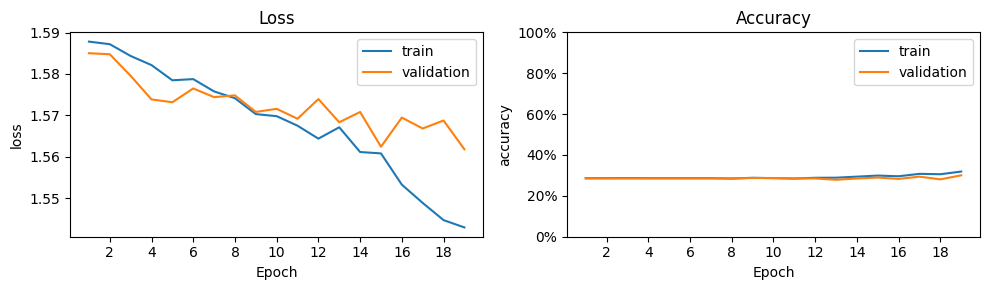

Epoch 2/24
  custom_reference_8: 40/2126 clips | batch loss=1.5976
  custom_reference_8: 80/2126 clips | batch loss=1.6507
  custom_reference_8: 120/2126 clips | batch loss=1.6717
  custom_reference_8: 152/2126 clips | batch loss=1.5585
  custom_reference_8: 200/2126 clips | batch loss=1.6035
  custom_reference_8: 232/2126 clips | batch loss=1.6090
  custom_reference_8: 272/2126 clips | batch loss=1.6733
  custom_reference_8: 320/2126 clips | batch loss=1.4710
  custom_reference_8: 360/2126 clips | batch loss=1.7186
  custom_reference_8: 400/2126 clips | batch loss=1.6156
  custom_reference_8: 440/2126 clips | batch loss=1.6631
  custom_reference_8: 488/2126 clips | batch loss=1.5065
  custom_reference_8: 528/2126 clips | batch loss=1.6112
  custom_reference_8: 568/2126 clips | batch loss=1.3381
  custom_reference_8: 616/2126 clips | batch loss=1.5570
  custom_reference_8: 656/2126 clips | batch loss=1.5583
  custom_reference_8: 696/2126 clips | batch loss=1.6925
  custom_reference_8: 

: 

In [5]:
try:
    screen_dir = run_screen(prepared)
except TimeoutError as error:
    suite_timed_out = True
    screen_dir = prepared.get('suite_run_dir')
    print(f'Suite time limit reached; saved partial results will be downloaded. {error}')


## Longer confirmation and validation-only freeze
Train the selected custom configuration and all three CNNs from scratch for 64 epochs, seeds 42/2026, at max(96, selected spatial size). Use identical splits, sampling and budgets; report mean/std validation metrics. Freeze every compatible checkpoint before opening test. No test evaluation after an incomplete suite.

In [ ]:
if suite_timed_out:
    print('Skipping confirmation because the screen did not complete.')
else:
    try:
        final_data = train_winner(prepared, screen_dir)
    except TimeoutError as error:
        suite_timed_out = True
        print(f'Suite time limit reached; saved partial results will be downloaded. {error}')


## Final test metrics, then playable test predictions
Evaluate frozen confirmations without reranking from test. Show up to five test videos/probabilities from the validation winner's predeclared seed 42. Metrics and reports are saved before display; rerunning this cell reuses saved results. These diagnostics are not independent surveillance-paper evidence.

In [ ]:
if screen_dir is None or suite_timed_out:
    print('Skipping final test evaluation because the suite is incomplete.')
else:
    try:
        final_report = final_evaluate(final_data, screen_dir)
    except TimeoutError as error:
        suite_timed_out = True
        print(f'Suite time limit reached; saved partial results will be downloaded. {error}')
artifact_archive = download_suite_artifacts(prepared, screen_dir)
print(f'Suite artifact archive: {artifact_archive}')
